# CardFlow TCG — Sistema Inteligente de Previsão e Gestão de Estoque para E-commerce TCG

## Introdução

Pequenos e-commerces frequentemente enfrentam dificuldades para prever demanda e gerenciar estoque de forma eficiente. Em nichos como Trading Card Games (TCG), esse problema se torna ainda mais crítico devido à alta volatilidade do mercado, lançamentos frequentes, produtos sazonais e mudanças rápidas no meta competitivo.

A motivação para este projeto surgiu a partir de um caso real: um conhecido tentou iniciar um e-commerce voltado para TCGs, mas enfrentou dificuldades relacionadas à previsão de demanda e gestão de estoque, o que comprometeu a continuidade do negócio.

Diante desse cenário, foi desenvolvido o **CardFlow**, um MVP orientado a dados para auxiliar pequenas lojas de TCG a identificar riscos de ruptura, excesso de estoque e padrões de demanda utilizando análise de dados e modelagem preditiva.

---

## Objetivo

Este projeto busca:

- Identificar produtos em risco de ruptura;
- Detectar excesso de estoque;
- Analisar padrões de venda e lucratividade;
- Simular problemas reais encontrados em bases de dados comerciais;
- Construir uma base analítica para apoiar futuras previsões de demanda;
- Avaliar modelos preditivos como suporte à tomada de decisão operacional.

---

## Conjunto de Dados

Os dados utilizados foram gerados para simular uma operação real de e-commerce de TCGs contendo:

- 250 produtos;
- Mais de 18 mil registros de vendas;
- Dados de Pokémon, Magic: The Gathering e Yu-Gi-Oh;
- Imperfeições propositais:
    - valores ausentes;
    - registros duplicados;
    - categorias inconsistentes;
    - outliers.

Essas imperfeições foram incluídas para aproximar o projeto de cenários encontrados em ambientes reais de negócio.

---

## Tecnologias utilizadas

- Python — linguagem principal do projeto;
- Pandas — manipulação e tratamento dos dados;
- Matplotlib — visualização gráfica;
- Scikit-learn — preparação, treinamento e avaliação dos modelos;
- Jupyter Notebook — desenvolvimento e documentação da análise.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

produtos = pd.read_csv('../backup/produtos_tcg.csv')
estoque = pd.read_csv('../backup/estoque_tcg.csv')
vendas = pd.read_csv('../backup/vendas_tcg.csv')

print(produtos.shape)
print(estoque.shape)
print(vendas.shape)

(250, 12)
(250, 8)
(18544, 9)


## Visão Geral dos Dados

Nesta etapa será realizada uma inspeção inicial dos datasets para compreender sua estrutura, identificar tipos de variáveis, verificar possíveis valores ausentes e validar a consistência geral dos dados.

Essa etapa é importante para identificar problemas antes do início da limpeza e análise exploratória.

In [2]:
# Informações gerais dos datasets

print('=== PRODUTOS ===')
produtos.info()

print('\n')

print('=== ESTOQUE ===')
estoque.info()

print('\n')

print('=== VENDAS ===')
vendas.info()

=== PRODUTOS ===
<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   produto_id         250 non-null    int64  
 1   nome_produto       250 non-null    str    
 2   categoria          250 non-null    str    
 3   jogo               250 non-null    str    
 4   set_colecao        250 non-null    str    
 5   raridade           245 non-null    str    
 6   preco_unitario     250 non-null    float64
 7   custo_unitario     250 non-null    float64
 8   data_lancamento    250 non-null    str    
 9   popularidade_base  250 non-null    int64  
 10  meta_relevancia    250 non-null    int64  
 11  fornecedor         242 non-null    str    
dtypes: float64(2), int64(3), str(7)
memory usage: 45.5 KB


=== ESTOQUE ===
<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
--

### Conclusões iniciais

A inspeção inicial mostrou que os datasets possuem estrutura consistente e relacionamento aparente entre as tabelas através da variável `produto_id`.

Alguns pontos importantes foram identificados:

- O conjunto contém 250 produtos e mais de 18 mil registros de vendas, fornecendo volume suficiente para análises e construção do MVP;
- Foram identificados valores ausentes nas colunas `raridade` e `fornecedor`;
- Variáveis relacionadas a datas (`data_lancamento`, `ultima_reposicao` e `data_venda`) foram carregadas como texto e exigirão conversão;
- Não foram identificados valores ausentes nas tabelas de estoque e vendas;
- Os datasets apresentam estrutura adequada para prosseguir com as etapas de limpeza, preparação e análise exploratória.

Essas observações indicam a necessidade de uma etapa de tratamento antes do início das análises de negócio.

## Diagnóstico Inicial dos Dados

Após verificar a estrutura geral dos datasets, será realizada uma análise inicial para identificar possíveis problemas de qualidade dos dados, incluindo:

- valores ausentes;
- registros duplicados;
- inconsistências;
- exemplos iniciais dos dados.

Essa etapa auxilia na definição das estratégias de tratamento que serão aplicadas posteriormente.

In [3]:
# Primeiras linhas dos datasets

print('=== PRODUTOS ===')
display(produtos.head())

print('=== ESTOQUE ===')
display(estoque.head())

print('=== VENDAS ===')
display(vendas.head())

# Valores ausentes

print('\nValores ausentes - Produtos')
print(produtos.isnull().sum())

print('\nValores ausentes - Estoque')
print(estoque.isnull().sum())

print('\nValores ausentes - Vendas')
print(vendas.isnull().sum())

# Duplicatas

print('\nDuplicatas em Produtos:')
print(produtos.duplicated().sum())

print('\nDuplicatas em Estoque:')
print(estoque.duplicated().sum())

print('\nDuplicatas em Vendas:')
print(vendas.duplicated().sum())

=== PRODUTOS ===


,produto_id,nome_produto,categoria,jogo,set_colecao,raridade,preco_unitario,custo_unitario,data_lancamento,popularidade_base,meta_relevancia,fornecedor
0,1,Carta 001 - Temporal Forces,Carta Avulsa,Pokémon,Temporal Forces,Ultra Rara,91.54,48.83,2025-07-13,43,0,Distribuidor B
1,2,Carta 002 - Duskmourn,Carta Avulsa,Magic,Duskmourn,Comum,49.12,29.61,2025-11-11,61,0,Distribuidor D
2,3,Carta 003 - Obsidian Flames,Carta Avulsa,Pokémon,Obsidian Flames,Secret Rare,72.68,32.95,2025-08-26,79,0,Distribuidor B
3,4,Carta 004 - Paradox Rift,Carta Avulsa,Pokémon,Paradox Rift,Rara,93.45,46.31,2026-03-25,23,0,Distribuidor B
4,5,Deck The Lost Caverns of Ixalan #005,Deck,Magic,The Lost Caverns of Ixalan,Ultra Rara,142.97,67.50,2025-10-22,81,0,Distribuidor A


=== ESTOQUE ===


,produto_id,estoque_inicial,estoque_atual,estoque_minimo,lead_time_dias,lote_reposicao,ultima_reposicao,status_estoque
0,1,30,0,7,29,10,2026-05-03,Crítico
1,2,46,0,11,8,5,2026-04-26,Crítico
2,3,25,0,6,16,5,2026-04-26,Crítico
3,4,82,48,20,22,30,2026-03-27,Excesso
4,5,34,0,8,27,50,2026-04-05,Crítico


=== VENDAS ===


,venda_id,data_venda,produto_id,quantidade_vendida,preco_venda_unitario,canal_venda,foi_promocao,evento_lancamento,observacao_demanda
0,1,2025-11-19,2,1,49.12,Site,0,1,Pico
1,2,2025-11-19,5,1,142.97,Site,0,0,Normal
2,3,2025-11-19,7,1,266.03,Marketplace,0,0,Normal
3,4,2025-11-19,10,5,27.39,Site,1,0,Pico
4,5,2025-11-19,11,1,38.05,Marketplace,0,0,Normal



Valores ausentes - Produtos
produto_id           0
nome_produto         0
categoria            0
jogo                 0
set_colecao          0
raridade             5
preco_unitario       0
custo_unitario       0
data_lancamento      0
popularidade_base    0
meta_relevancia      0
fornecedor           8
dtype: int64

Valores ausentes - Estoque
produto_id          0
estoque_inicial     0
estoque_atual       0
estoque_minimo      0
lead_time_dias      0
lote_reposicao      0
ultima_reposicao    0
status_estoque      0
dtype: int64

Valores ausentes - Vendas
venda_id                0
data_venda              0
produto_id              0
quantidade_vendida      0
preco_venda_unitario    0
canal_venda             0
foi_promocao            0
evento_lancamento       0
observacao_demanda      0
dtype: int64

Duplicatas em Produtos:
0

Duplicatas em Estoque:
0

Duplicatas em Vendas:
266


### Conclusões do diagnóstico inicial

A análise inicial revelou alguns problemas de qualidade de dados que precisarão ser tratados antes das análises exploratórias.

Principais observações:

- Foram identificados valores ausentes na tabela de produtos:
    - `raridade`: 5 registros ausentes;
    - `fornecedor`: 8 registros ausentes;

- Não foram encontrados valores ausentes nas tabelas de estoque e vendas;

- Foram identificados 266 registros duplicados na tabela de vendas;

- Não foram encontradas duplicatas nas tabelas de produtos e estoque.

Os resultados sugerem um cenário relativamente próximo ao encontrado em ambientes reais, onde dados incompletos e registros redundantes são comuns. Portanto, será necessário realizar uma etapa de limpeza e padronização antes da continuidade da análise.

## Limpeza e Preparação dos Dados

Nesta etapa serão realizados tratamentos para corrigir inconsistências identificadas anteriormente.

As ações incluem:

- tratamento de valores ausentes;
- remoção de registros duplicados;
- conversão de variáveis de data;
- padronização de categorias inconsistentes.

Essas etapas são fundamentais para garantir maior confiabilidade das análises futuras.

In [4]:
# Cópias de segurança antes das alterações

produtos_limpo = produtos.copy()
estoque_limpo = estoque.copy()
vendas_limpo = vendas.copy()

# ======================
# Tratamento de nulos
# ======================

produtos_limpo['raridade'] = (
    produtos_limpo['raridade']
    .fillna('Desconhecida')
)

produtos_limpo['fornecedor'] = (
    produtos_limpo['fornecedor']
    .fillna('Fornecedor não informado')
)

# ======================
# Remover duplicatas
# ======================

print('Duplicatas antes:', vendas_limpo.duplicated().sum())

vendas_limpo = vendas_limpo.drop_duplicates()

print('Duplicatas depois:', vendas_limpo.duplicated().sum())

# ======================
# Conversão de datas
# ======================

produtos_limpo['data_lancamento'] = pd.to_datetime(
    produtos_limpo['data_lancamento'],
    errors='coerce'
)

estoque_limpo['ultima_reposicao'] = pd.to_datetime(
    estoque_limpo['ultima_reposicao'],
    errors='coerce'
)

# Conversão robusta de datas de venda com formatos mistos

datas_iso = pd.to_datetime(
    vendas_limpo['data_venda'],
    format='%Y-%m-%d',
    errors='coerce'
)

datas_br = pd.to_datetime(
    vendas_limpo['data_venda'],
    format='%d/%m/%Y',
    errors='coerce'
)

vendas_limpo['data_venda'] = datas_iso.fillna(datas_br)


# ======================
# Padronizar canais
# ======================

mapa_canais = {

    'site':'Site',
    'SITE':'Site',

    'marketplace':'Marketplace',
    'Market Place':'Marketplace',

    'loja fisica':'Loja Física',
    'LOJA FÍSICA':'Loja Física'

}

vendas_limpo['canal_venda'] = (
    vendas_limpo['canal_venda']
    .replace(mapa_canais)
)

print('\nValores únicos após padronização:\n')

print(
    vendas_limpo['canal_venda']
    .value_counts()
)

Duplicatas antes: 266
Duplicatas depois: 0

Valores únicos após padronização:

canal_venda
Site           10871
Marketplace     5499
Loja Física     1908
Name: count, dtype: int64


### Conclusões da etapa de limpeza

A etapa de preparação dos dados foi concluída com sucesso.

As principais transformações realizadas foram:

- preenchimento de valores ausentes em `raridade` e `fornecedor`;
- remoção de 266 registros duplicados na tabela de vendas;
- conversão das variáveis temporais para o formato de data;
- padronização dos canais de venda inconsistentes.

Após os tratamentos aplicados, os dados encontram-se mais consistentes e adequados para análises exploratórias e geração de indicadores.

A limpeza dos dados reduz ruídos e aumenta a confiabilidade dos resultados obtidos nas próximas etapas.

## Engenharia de Atributos

Nesta etapa serão criadas novas variáveis derivadas a partir dos dados existentes.

O objetivo é enriquecer as análises futuras e facilitar a construção de indicadores de negócio.

Serão criadas variáveis relacionadas a:

- faturamento;
- margem;
- dia da semana;
- mês;
- indicadores de estoque.

In [5]:
# ======================
# Métricas financeiras
# ======================

vendas_limpo = vendas_limpo.merge(

    produtos_limpo[
        ['produto_id','custo_unitario']
    ],

    on='produto_id',
    how='left'

)

vendas_limpo['faturamento'] = (

    vendas_limpo['quantidade_vendida']
    *
    vendas_limpo['preco_venda_unitario']

)

vendas_limpo['lucro_estimado'] = (

    vendas_limpo['quantidade_vendida']
    *
    (
        vendas_limpo['preco_venda_unitario']
        -
        vendas_limpo['custo_unitario']
    )

)

# ======================
# Variáveis temporais
# ======================

vendas_limpo['dia_semana'] = (
    vendas_limpo['data_venda']
    .dt.day_name()
)

vendas_limpo['mes'] = (
    vendas_limpo['data_venda']
    .dt.month
)

# ======================
# Indicador de risco
# ======================

estoque_limpo['risco_ruptura'] = np.where(

    estoque_limpo['estoque_atual']
    <=
    estoque_limpo['estoque_minimo']*1.5,

    'Alto',

    'Baixo'

)

# Verificação rápida

display(
    vendas_limpo.head()
)

display(
    estoque_limpo.head()
)

,venda_id,data_venda,produto_id,quantidade_vendida,preco_venda_unitario,canal_venda,foi_promocao,evento_lancamento,observacao_demanda,custo_unitario,faturamento,lucro_estimado,dia_semana,mes
0,1,2025-11-19,2,1,49.12,Site,0,1,Pico,29.61,49.12,19.51,Wednesday,11
1,2,2025-11-19,5,1,142.97,Site,0,0,Normal,67.50,142.97,75.47,Wednesday,11
2,3,2025-11-19,7,1,266.03,Marketplace,0,0,Normal,177.12,266.03,88.91,Wednesday,11
3,4,2025-11-19,10,5,27.39,Site,1,0,Pico,13.82,136.95,67.85,Wednesday,11
4,5,2025-11-19,11,1,38.05,Marketplace,0,0,Normal,17.19,38.05,20.86,Wednesday,11


,produto_id,estoque_inicial,estoque_atual,estoque_minimo,lead_time_dias,lote_reposicao,ultima_reposicao,status_estoque,risco_ruptura
0,1,30,0,7,29,10,2026-05-03,Crítico,Alto
1,2,46,0,11,8,5,2026-04-26,Crítico,Alto
2,3,25,0,6,16,5,2026-04-26,Crítico,Alto
3,4,82,48,20,22,30,2026-03-27,Excesso,Baixo
4,5,34,0,8,27,50,2026-04-05,Crítico,Alto


### Conclusões da engenharia de atributos

Novas variáveis foram criadas para enriquecer as análises e gerar indicadores mais próximos de um ambiente de negócio real.

As principais métricas derivadas incluem:

- faturamento estimado por venda;
- lucro estimado;
- informações temporais;
- classificação de risco de ruptura.

Essas novas variáveis permitem análises mais profundas relacionadas ao comportamento de vendas, desempenho financeiro e gestão de estoque.

## Indicadores Gerais do Negócio

Antes das análises exploratórias detalhadas, serão calculados alguns indicadores gerais para compreender o cenário operacional do e-commerce.

Esses indicadores fornecem uma visão macro do negócio e ajudam a identificar possíveis oportunidades e riscos.

In [6]:
# ======================
# KPIs gerais
# ======================

total_produtos = produtos_limpo.shape[0]

total_vendas = len(vendas_limpo)

faturamento_total = (
    vendas_limpo['faturamento']
    .sum()
)

lucro_total = (
    vendas_limpo['lucro_estimado']
    .sum()
)

produtos_criticos = (
    estoque_limpo[
        estoque_limpo['status_estoque']=='Crítico'
    ]
    .shape[0]
)

produtos_excesso = (
    estoque_limpo[
        estoque_limpo['status_estoque']=='Excesso'
    ]
    .shape[0]
)

ticket_medio = (

    vendas_limpo['faturamento']
    .mean()

)

print(f'Total de produtos: {total_produtos}')

print(f'Total de vendas: {total_vendas:,}')

print(f'Faturamento total: R$ {faturamento_total:,.2f}')

print(f'Lucro estimado: R$ {lucro_total:,.2f}')

print(f'Ticket médio: R$ {ticket_medio:,.2f}')

print(f'Produtos críticos: {produtos_criticos}')

print(f'Produtos em excesso: {produtos_excesso}')

Total de produtos: 250
Total de vendas: 18,278
Faturamento total: R$ 2,681,901.56
Lucro estimado: R$ 1,151,799.07
Ticket médio: R$ 146.73
Produtos críticos: 217
Produtos em excesso: 23


### Conclusões dos indicadores gerais

Os indicadores iniciais revelam uma operação com volume relevante de vendas e faturamento, sugerindo um cenário próximo ao de um pequeno ou médio e-commerce especializado.

Principais observações:

- Foram identificados 250 produtos cadastrados;
- O histórico possui mais de 18 mil registros de vendas;
- O faturamento estimado ultrapassou R$ 2,6 milhões;
- O lucro estimado foi superior a R$ 1,1 milhão;
- O ticket médio ficou próximo de R$ 147 por venda.

Entretanto, foi identificado um número elevado de produtos classificados como críticos em estoque.

Esse resultado pode indicar oportunidades de melhoria relacionadas ao planejamento de reposição, previsão de demanda e gestão operacional.

## Análise Exploratória — Distribuição por TCG

Nesta etapa será analisada a distribuição dos produtos entre os diferentes jogos comercializados.

Essa análise permite compreender o foco operacional do negócio e identificar possíveis concentrações de catálogo.

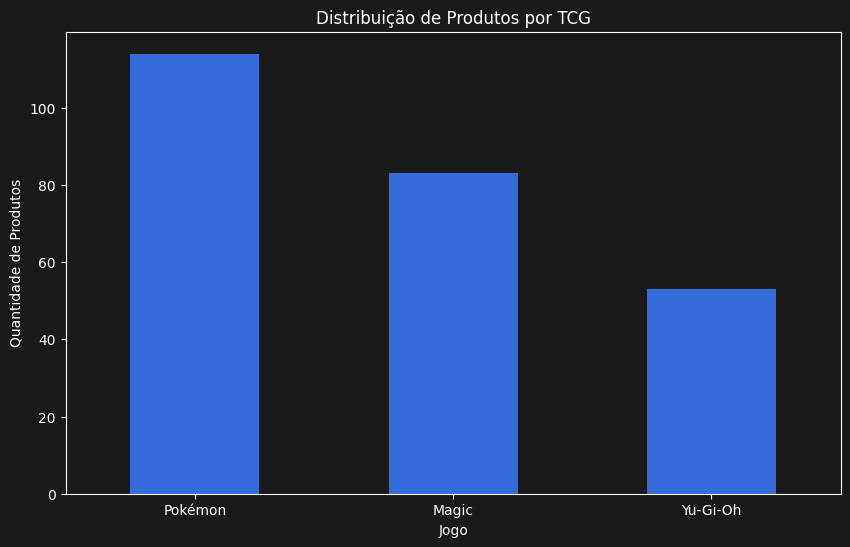

In [7]:
tcg_dist = (
    produtos_limpo['jogo']
    .value_counts()
)

plt.figure(figsize=[10,6])

tcg_dist.plot(
    kind='bar'
)

plt.title(
    'Distribuição de Produtos por TCG'
)

plt.xlabel(
    'Jogo'
)

plt.ylabel(
    'Quantidade de Produtos'
)

plt.xticks(rotation=0)

plt.show()

### Interpretação

A distribuição dos produtos mostra uma maior concentração de itens relacionados ao universo Pokémon, seguido por Magic: The Gathering e Yu-Gi-Oh.

Essa distribuição pode refletir tendências de mercado, popularidade entre consumidores ou decisões estratégicas relacionadas ao catálogo da loja.

A predominância de determinados TCGs pode impactar diretamente a gestão de estoque, padrões de venda e necessidades futuras de reposição.

## Análise Exploratória — Situação do Estoque

Nesta etapa será analisada a distribuição atual dos produtos entre os diferentes estados de estoque.

O objetivo é identificar possíveis concentrações de produtos críticos ou excesso de estoque.

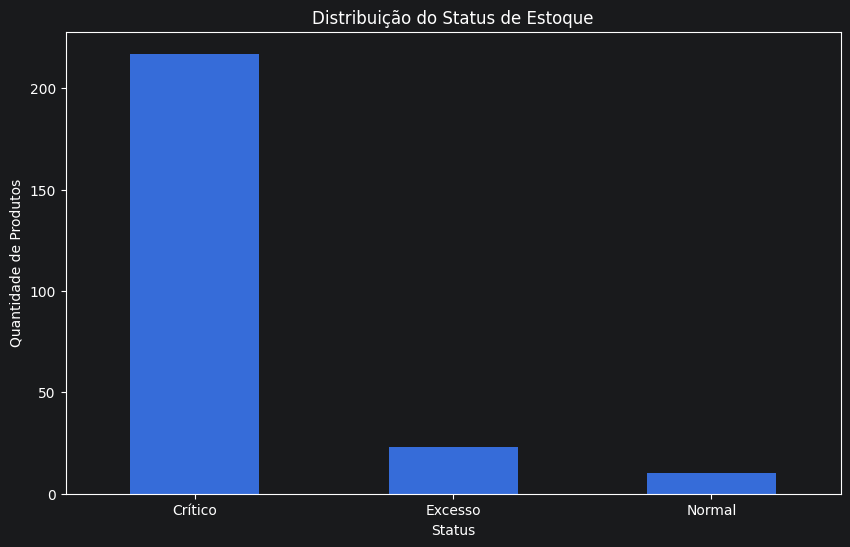

In [8]:
estoque_status = (
    estoque_limpo['status_estoque']
    .value_counts()
)

plt.figure(figsize=[10,6])

estoque_status.plot(
    kind='bar'
)

plt.title(
    'Distribuição do Status de Estoque'
)

plt.xlabel(
    'Status'
)

plt.ylabel(
    'Quantidade de Produtos'
)

plt.xticks(rotation=0)

plt.show()

### Interpretação

A análise da situação do estoque revelou uma concentração extremamente elevada de produtos classificados como críticos.

Entre os 250 produtos analisados:

- 217 encontram-se em situação crítica;
- 23 apresentam excesso de estoque;
- apenas 10 encontram-se em situação considerada normal.

Esse comportamento sugere possíveis problemas relacionados ao planejamento de reposição ou à previsão de demanda.

A elevada quantidade de produtos críticos reforça a necessidade de ferramentas capazes de antecipar riscos de ruptura e apoiar decisões mais eficientes de gestão de estoque — justamente o objetivo central do CardFlow.

## Análise Exploratória — Produtos Mais Vendidos

Nesta etapa serão identificados os produtos com maior volume de vendas.

O objetivo é compreender quais itens concentram a maior demanda e investigar possíveis relações com os problemas identificados no estoque.

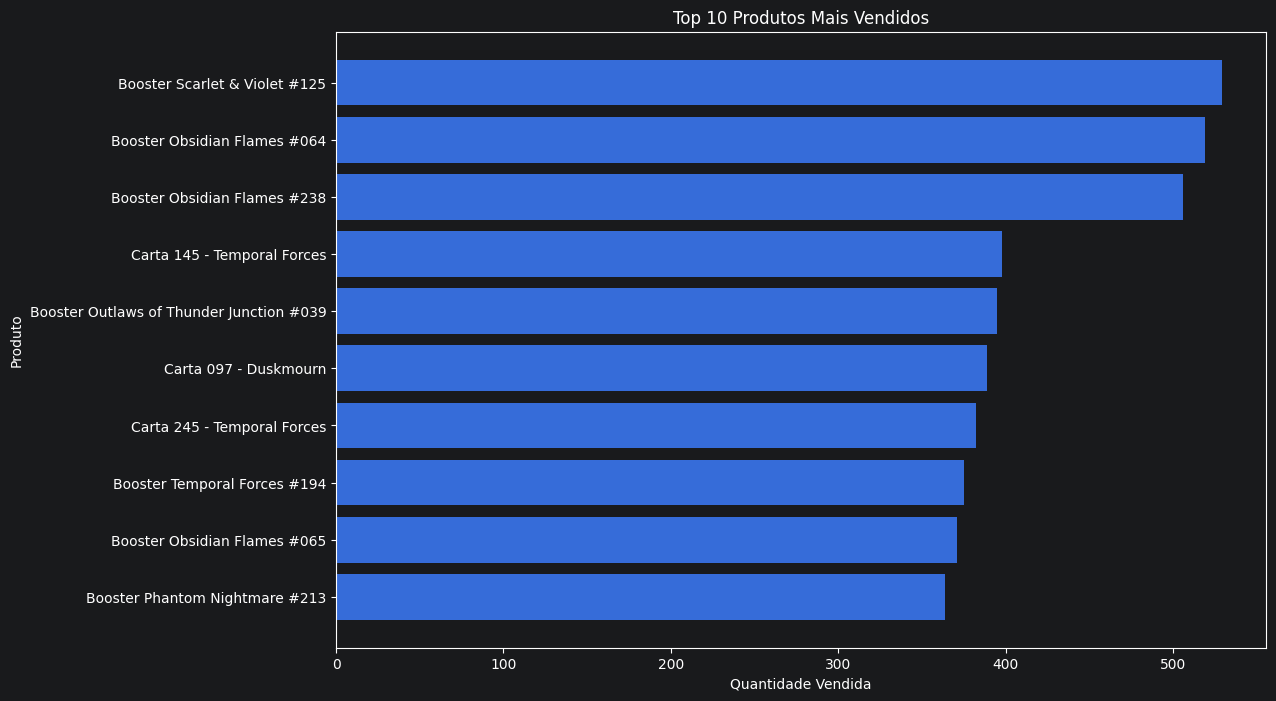

In [9]:
top_produtos = (

    vendas_limpo
    .groupby('produto_id')['quantidade_vendida']
    .sum()
    .sort_values(
        ascending=False
    )
    .head(10)

)

nomes = produtos_limpo[
    ['produto_id','nome_produto']
]

top_produtos = (
    top_produtos
    .reset_index()
    .merge(
        nomes,
        on='produto_id'
    )
)

plt.figure(figsize=[12,8])

plt.barh(

    top_produtos['nome_produto'],
    top_produtos['quantidade_vendida']

)

plt.title(
    'Top 10 Produtos Mais Vendidos'
)

plt.xlabel(
    'Quantidade Vendida'
)

plt.ylabel(
    'Produto'
)

plt.gca().invert_yaxis()

plt.show()

### Interpretação

A análise dos produtos mais vendidos mostrou forte concentração de boosters entre os itens de maior demanda.

Esse comportamento é coerente com o mercado de TCG, já que boosters costumam apresentar alta rotatividade devido a:

- lançamentos frequentes;
- comportamento de colecionadores;
- busca por cartas raras;
- mudanças no meta competitivo.

Esse padrão ajuda a explicar parcialmente o elevado número de produtos em situação crítica de estoque, já que itens com maior volume de vendas tendem a consumir estoque em ritmo acelerado.

A identificação antecipada desses produtos representa uma oportunidade importante para estratégias de reposição automatizada.

## Análise Exploratória — Evolução Temporal das Vendas

Nesta etapa será analisado o comportamento das vendas ao longo do tempo.

O objetivo é identificar tendências, oscilações e possíveis padrões temporais que possam influenciar decisões futuras relacionadas ao estoque.

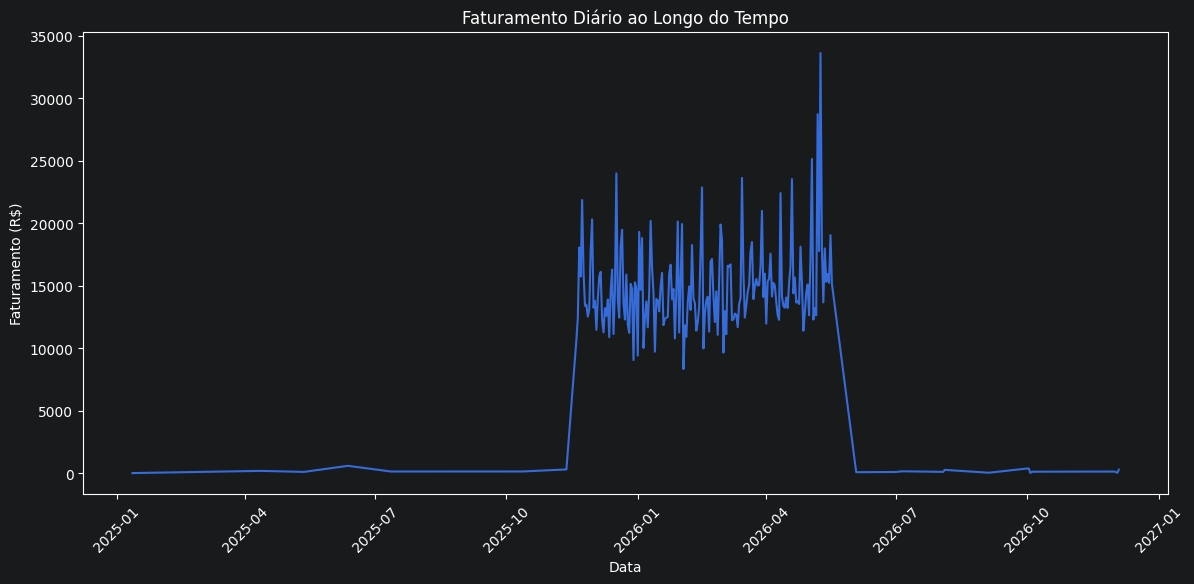

In [10]:
vendas_dia = (

    vendas_limpo
    .groupby('data_venda')['faturamento']
    .sum()

)

plt.figure(figsize=[14,6])

plt.plot(
    vendas_dia.index,
    vendas_dia.values
)

plt.title(
    'Faturamento Diário ao Longo do Tempo'
)

plt.xlabel(
    'Data'
)

plt.ylabel(
    'Faturamento (R$)'
)

plt.xticks(rotation=45)

plt.show()

### Interpretação

A análise temporal revelou períodos concentrados de faturamento elevado, intercalados com intervalos de atividade significativamente menor.

Também foi observado um comportamento incomum na distribuição temporal das vendas, sugerindo possíveis efeitos relacionados a:

- eventos de lançamento;
- promoções;
- sazonalidade;
- ou inconsistências introduzidas propositalmente para simular cenários reais.

Esse resultado reforça a importância de investigar padrões temporais antes da construção de modelos preditivos, já que anomalias podem influenciar significativamente previsões futuras.

In [11]:
print('Data mínima:')
print(vendas_limpo['data_venda'].min())

print('\nData máxima:')
print(vendas_limpo['data_venda'].max())

print('\nValores ausentes:')
print(vendas_limpo['data_venda'].isna().sum())

Data mínima:
2025-01-12 00:00:00

Data máxima:
2026-12-04 00:00:00

Valores ausentes:
0


### Validação temporal

Foi realizada uma verificação adicional da variável temporal para garantir consistência após a conversão dos formatos de data.

Essa validação teve como objetivo identificar possíveis inconsistências que pudessem impactar análises temporais futuras.

### Conclusão

A validação confirmou que não houve perda de registros após a conversão das datas.

Entretanto, foi observado um comportamento temporal concentrado, possivelmente associado à dinâmica de lançamentos e eventos simulados no conjunto de dados.

### Observação metodológica

A série temporal apresentou períodos concentrados de faturamento significativamente maiores.

Esse comportamento pode ser explicado pela dinâmica do mercado de TCG, que frequentemente apresenta picos de demanda associados a:

- lançamentos;
- alterações de meta;
- promoções;
- eventos sazonais.

Esse padrão reforça a necessidade de modelos capazes de capturar variações abruptas de demanda.

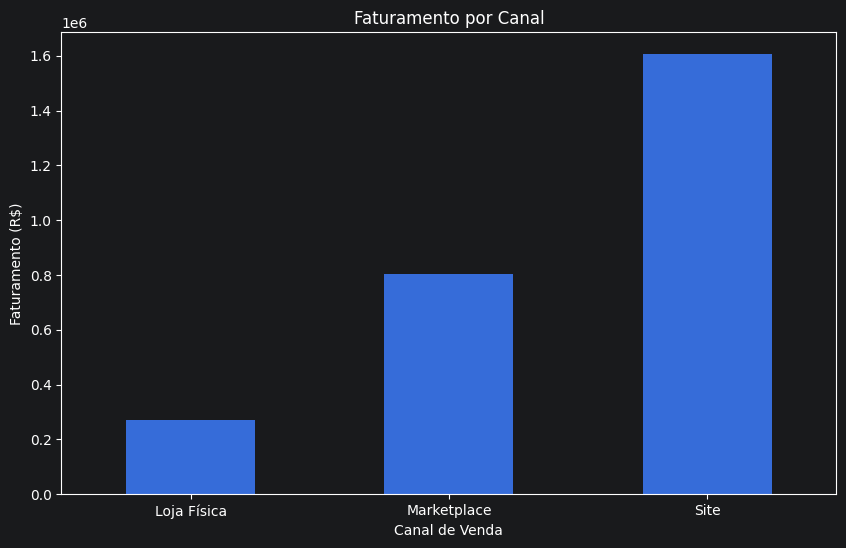

In [12]:
faturamento_canal = (

    vendas_limpo
    .groupby('canal_venda')['faturamento']
    .sum()

)

plt.figure(figsize=[10,6])

faturamento_canal.plot(
    kind='bar'
)

plt.title(
    'Faturamento por Canal'
)

plt.xlabel(
    'Canal de Venda'
)

plt.ylabel(
    'Faturamento (R$)'
)

plt.xticks(rotation=0)

plt.show()

### Interpretação

A análise do faturamento por canal mostrou uma forte concentração das vendas no canal online próprio da empresa.

Principais observações:

- O site representa a maior parcela do faturamento total;
- O marketplace aparece como segundo principal canal;
- A loja física possui participação significativamente menor.

Esse comportamento é compatível com operações modernas de e-commerce especializado, especialmente em nichos como TCG, onde clientes frequentemente acompanham lançamentos e realizam compras online.

Os resultados sugerem que estratégias de otimização no canal principal podem gerar impacto significativo sobre a receita total da operação.

## Análise Exploratória — Produtos Críticos por TCG

Nesta etapa será analisada a distribuição dos produtos em situação crítica de estoque entre os diferentes jogos comercializados.

O objetivo é identificar quais segmentos apresentam maior risco operacional.

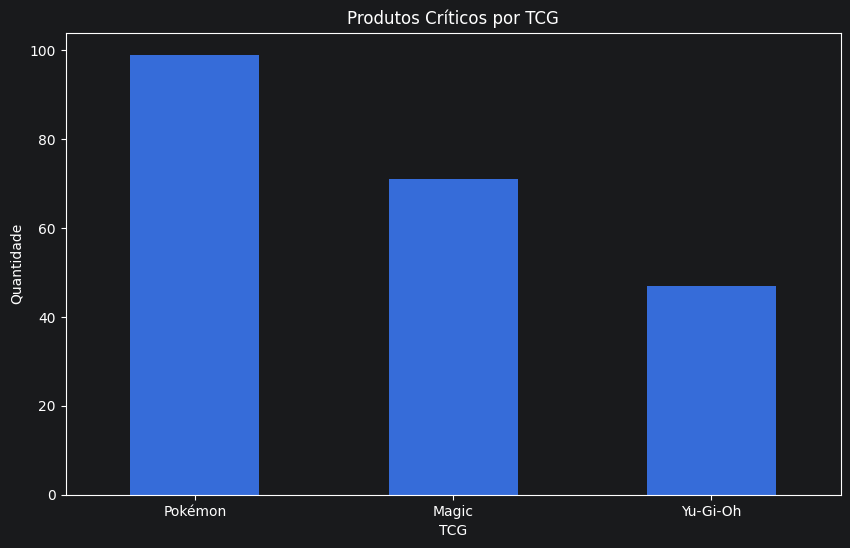

In [13]:
criticos = (

    estoque_limpo[
        estoque_limpo['status_estoque']=='Crítico'
    ]

)

criticos_tcg = (

    criticos
    .merge(
        produtos_limpo[
            ['produto_id','jogo']
        ],
        on='produto_id'
    )

    ['jogo']

    .value_counts()

)

plt.figure(figsize=[10,6])

criticos_tcg.plot(
    kind='bar'
)

plt.title(
    'Produtos Críticos por TCG'
)

plt.xlabel(
    'TCG'
)

plt.ylabel(
    'Quantidade'
)

plt.xticks(rotation=0)

plt.show()

### Interpretação

A análise dos produtos críticos por TCG mostrou que Pokémon concentra a maior quantidade de itens em situação crítica de estoque.

Esse comportamento acompanha resultados observados anteriormente:

- Pokémon possui o maior catálogo;
- diversos produtos Pokémon aparecem entre os itens mais vendidos;
- boosters relacionados ao universo Pokémon apresentam alta demanda.

Esses resultados sugerem que o elevado volume de vendas pode estar contribuindo diretamente para o aumento do risco operacional nesse segmento.

Esse tipo de informação é particularmente relevante para estratégias futuras de reposição automática e previsão de demanda — objetivos centrais do CardFlow.

## Análise Exploratória — Produtos Mais Lucrativos

Nem sempre os produtos mais vendidos representam os maiores retornos financeiros.

Nesta etapa será analisado o lucro acumulado por produto para identificar itens estratégicos para o negócio.

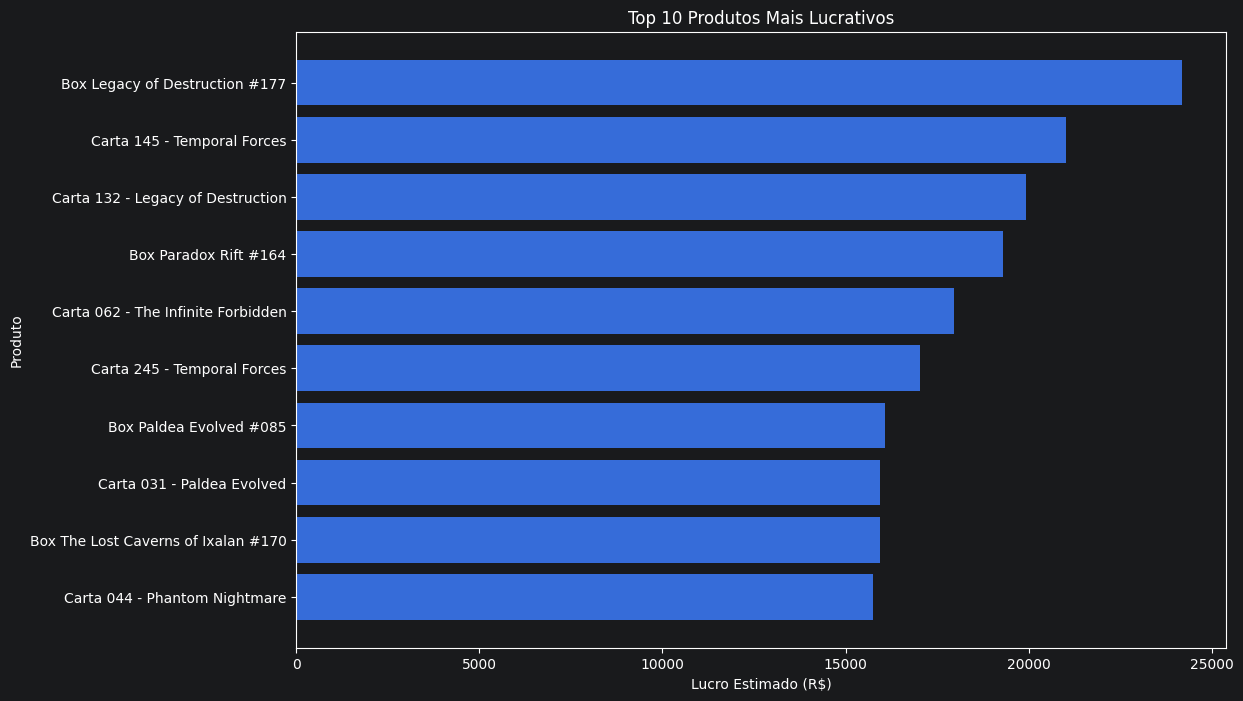

In [14]:
top_lucro = (

    vendas_limpo

    .groupby('produto_id')['lucro_estimado']

    .sum()

    .sort_values(
        ascending=False
    )

    .head(10)

)

top_lucro = (

    top_lucro
    .reset_index()

    .merge(

        produtos_limpo[
            ['produto_id','nome_produto']
        ],

        on='produto_id'

    )

)

plt.figure(figsize=[12,8])

plt.barh(

    top_lucro['nome_produto'],

    top_lucro['lucro_estimado']

)

plt.title(
    'Top 10 Produtos Mais Lucrativos'
)

plt.xlabel(
    'Lucro Estimado (R$)'
)

plt.ylabel(
    'Produto'
)

plt.gca().invert_yaxis()

plt.show()

### Interpretação

A análise dos produtos mais lucrativos revelou diferenças importantes em relação aos produtos com maior volume de vendas.

Enquanto boosters dominaram os rankings de quantidade vendida, produtos de maior valor agregado — como boxes e cartas específicas — apresentaram maior contribuição para o lucro total.

Esse resultado mostra que:

- produtos mais vendidos não necessariamente são os mais rentáveis;
- itens premium podem gerar maior retorno financeiro;
- decisões de estoque devem considerar não apenas volume de vendas, mas também impacto financeiro.

Essa análise reforça a importância de indicadores múltiplos no processo de tomada de decisão.

## Próximos Passos

As análises exploratórias permitiram compreender padrões relevantes relacionados a vendas, lucratividade e comportamento do estoque.

A próxima etapa do projeto será utilizar essas informações para desenvolver mecanismos preditivos capazes de antecipar riscos operacionais e apoiar decisões futuras.

# Modelagem Preditiva — Previsão de Demanda

Após a análise exploratória, o próximo passo consiste em construir um modelo capaz de prever demanda futura.

O objetivo do CardFlow é antecipar riscos de ruptura de estoque e apoiar decisões de reposição de produtos.

Para isso, serão utilizadas variáveis relacionadas a:

- comportamento histórico de vendas;
- características dos produtos;
- informações de estoque;
- fatores temporais;
- eventos promocionais.

A variável alvo será a quantidade vendida.

In [15]:
# ======================
# Construção da base ML
# ======================

base_ml = (

    vendas_limpo

    .merge(

        produtos_limpo,

        on='produto_id'

    )

    .merge(

        estoque_limpo,

        on='produto_id'

    )

)

print(base_ml.shape)

display(
    base_ml.head()
)

(18278, 33)


,venda_id,data_venda,produto_id,quantidade_vendida,preco_venda_unitario,canal_venda,foi_promocao,evento_lancamento,observacao_demanda,custo_unitario_x,...,meta_relevancia,fornecedor,estoque_inicial,estoque_atual,estoque_minimo,lead_time_dias,lote_reposicao,ultima_reposicao,status_estoque,risco_ruptura
0,1,2025-11-19,2,1,49.12,Site,0,1,Pico,29.61,...,0,Distribuidor D,46,0,11,8,5,2026-04-26,Crítico,Alto
1,2,2025-11-19,5,1,142.97,Site,0,0,Normal,67.50,...,0,Distribuidor A,34,0,8,27,50,2026-04-05,Crítico,Alto
2,3,2025-11-19,7,1,266.03,Marketplace,0,0,Normal,177.12,...,0,Distribuidor D,48,0,12,30,10,2026-04-03,Crítico,Alto
3,4,2025-11-19,10,5,27.39,Site,1,0,Pico,13.82,...,1,Distribuidor B,155,0,38,23,10,2026-04-02,Crítico,Alto
4,5,2025-11-19,11,1,38.05,Marketplace,0,0,Normal,17.19,...,0,Distribuidor A,107,0,26,15,50,2026-05-07,Crítico,Alto


### Objetivo da preparação

Nesta etapa os dados provenientes de vendas, produtos e estoque foram integrados em uma única estrutura analítica.

Essa unificação permitirá disponibilizar ao modelo informações mais ricas sobre:

- características dos produtos;
- comportamento operacional;
- informações de demanda;
- situação do estoque.

In [16]:
base_ml.info()

<class 'pandas.DataFrame'>
RangeIndex: 18278 entries, 0 to 18277
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   venda_id              18278 non-null  int64         
 1   data_venda            18278 non-null  datetime64[us]
 2   produto_id            18278 non-null  int64         
 3   quantidade_vendida    18278 non-null  int64         
 4   preco_venda_unitario  18278 non-null  float64       
 5   canal_venda           18278 non-null  str           
 6   foi_promocao          18278 non-null  int64         
 7   evento_lancamento     18278 non-null  int64         
 8   observacao_demanda    18278 non-null  str           
 9   custo_unitario_x      18278 non-null  float64       
 10  faturamento           18278 non-null  float64       
 11  lucro_estimado        18278 non-null  float64       
 12  dia_semana            18278 non-null  str           
 13  mes                   18278

In [17]:
# ======================
# Ajuste pós-merge
# ======================

base_ml = (

    base_ml

    .drop(
        columns=['custo_unitario_x']
    )

    .rename(
        columns={
            'custo_unitario_y':'custo_unitario'
        }
    )

)

base_ml.info()

<class 'pandas.DataFrame'>
RangeIndex: 18278 entries, 0 to 18277
Data columns (total 32 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   venda_id              18278 non-null  int64         
 1   data_venda            18278 non-null  datetime64[us]
 2   produto_id            18278 non-null  int64         
 3   quantidade_vendida    18278 non-null  int64         
 4   preco_venda_unitario  18278 non-null  float64       
 5   canal_venda           18278 non-null  str           
 6   foi_promocao          18278 non-null  int64         
 7   evento_lancamento     18278 non-null  int64         
 8   observacao_demanda    18278 non-null  str           
 9   faturamento           18278 non-null  float64       
 10  lucro_estimado        18278 non-null  float64       
 11  dia_semana            18278 non-null  str           
 12  mes                   18278 non-null  int32         
 13  nome_produto          18278

### Ajustes pós-integração

Durante a integração das tabelas foram identificadas colunas duplicadas geradas automaticamente pelos processos de junção.

Foi realizado um tratamento adicional para remover redundâncias e manter uma estrutura mais organizada para a modelagem preditiva.

In [18]:
colunas_cat = (

    base_ml

    .select_dtypes(
        include='object'
    )

    .columns

)

print(colunas_cat)

Index(['canal_venda', 'observacao_demanda', 'dia_semana', 'nome_produto',
       'categoria', 'jogo', 'set_colecao', 'raridade', 'fornecedor',
       'status_estoque', 'risco_ruptura'],
      dtype='str')


C:\Users\User\AppData\Local\Temp\ipykernel_21352\3029629994.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  .select_dtypes(


In [19]:
# ======================
# Seleção de variáveis para o modelo
# ======================

features = [
    'preco_venda_unitario',
    'canal_venda',
    'foi_promocao',
    'evento_lancamento',
    'observacao_demanda',
    'dia_semana',
    'mes',
    'categoria',
    'jogo',
    'set_colecao',
    'raridade',
    'preco_unitario',
    'custo_unitario',
    'popularidade_base',
    'meta_relevancia',
    'fornecedor',
    'estoque_inicial',
    'estoque_atual',
    'estoque_minimo',
    'lead_time_dias',
    'lote_reposicao'
]

target = 'quantidade_vendida'

X = base_ml[features]
y = base_ml[target]

print(X.shape)
print(y.shape)

(18278, 21)
(18278,)


### Seleção de variáveis

Para a modelagem preditiva, foram selecionadas variáveis relacionadas a preço, produto, estoque, canal de venda, promoção e características temporais.

Algumas colunas foram removidas para evitar vazamento de informação, especialmente métricas calculadas diretamente a partir da variável alvo, como `faturamento` e `lucro_estimado`.

A variável alvo definida foi `quantidade_vendida`, representando a demanda observada.

## Preparação para Modelagem

Como o conjunto possui variáveis numéricas e categóricas, será utilizada uma etapa de pré-processamento automatizada.

Variáveis categóricas serão transformadas utilizando codificação apropriada, permitindo que algoritmos de Machine Learning utilizem essas informações durante o treinamento.

A utilização de pipelines também reduz riscos de inconsistências entre treino e teste.

In [20]:
from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder

# ======================
# Separação de colunas
# ======================

colunas_categoricas = X.select_dtypes(
    include='str'
).columns

colunas_numericas = X.select_dtypes(
    exclude='str'
).columns

print('Categóricas:\n')
print(colunas_categoricas)

print('\nNuméricas:\n')
print(colunas_numericas)

# ======================
# Pré-processador
# ======================

preprocessador = ColumnTransformer(

    transformers=[

        (

            'cat',

            OneHotEncoder(
                handle_unknown='ignore'
            ),

            colunas_categoricas

        )

    ],

    remainder='passthrough'

)

# ======================
# treino e teste
# ======================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42

)

print('\nTreino:',X_train.shape)

print('Teste:',X_test.shape)

Categóricas:

Index(['canal_venda', 'observacao_demanda', 'dia_semana', 'categoria', 'jogo',
       'set_colecao', 'raridade', 'fornecedor'],
      dtype='str')

Numéricas:

Index(['preco_venda_unitario', 'foi_promocao', 'evento_lancamento', 'mes',
       'preco_unitario', 'custo_unitario', 'popularidade_base',
       'meta_relevancia', 'estoque_inicial', 'estoque_atual', 'estoque_minimo',
       'lead_time_dias', 'lote_reposicao'],
      dtype='str')

Treino: (14622, 21)
Teste: (3656, 21)


## Treinamento de Modelos Base

Nesta etapa serão treinados modelos iniciais para prever a quantidade vendida.

A comparação entre diferentes algoritmos permite avaliar qual abordagem apresenta melhor desempenho para o problema de previsão de demanda.

Serão testados modelos de regressão com diferentes níveis de complexidade.

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ======================
# Função de avaliação
# ======================

def avaliar_modelo(nome_modelo, modelo, X_test, y_test):

    previsoes = modelo.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        previsoes
    )

    rmse = mean_squared_error(
        y_test,
        previsoes
    ) ** 0.5

    r2 = r2_score(
        y_test,
        previsoes
    )

    return {
        'modelo': nome_modelo,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    }

# ======================
# Modelo 1: Regressão Linear
# ======================

modelo_lr = Pipeline(
    steps=[
        ('preprocessador', preprocessador),
        ('modelo', LinearRegression())
    ]
)

modelo_lr.fit(
    X_train,
    y_train
)

# ======================
# Modelo 2: Random Forest
# ======================

modelo_rf = Pipeline(
    steps=[
        ('preprocessador', preprocessador),
        (
            'modelo',
            RandomForestRegressor(
                n_estimators=100,
                max_depth=10,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

modelo_rf.fit(
    X_train,
    y_train
)

# ======================
# Comparação
# ======================

resultados = []

resultados.append(
    avaliar_modelo(
        'Regressão Linear',
        modelo_lr,
        X_test,
        y_test
    )
)

resultados.append(
    avaliar_modelo(
        'Random Forest',
        modelo_rf,
        X_test,
        y_test
    )
)

resultados_df = pd.DataFrame(
    resultados
)

display(resultados_df)

,modelo,MAE,RMSE,R2
0,Regressão Linear,0.739373,1.54431,0.267496
1,Random Forest,0.818562,1.90009,-0.108892


### Resultados iniciais

Os modelos apresentaram comportamentos significativamente diferentes.

A regressão linear apresentou melhor desempenho em todas as métricas avaliadas:

- menor erro absoluto;
- menor erro quadrático;
- maior capacidade explicativa.

Já a Random Forest apresentou desempenho inferior, inclusive com coeficiente R² negativo.

Esse resultado sugere que, para os dados atuais, relações mais simples e lineares podem representar melhor o comportamento observado.

In [22]:
from sklearn.ensemble import HistGradientBoostingRegressor

modelo_hgb_reg = Pipeline(

    steps=[

        (
            'preprocessador',
            preprocessador
        ),

        (

            'modelo',

            HistGradientBoostingRegressor(

                max_iter=200,

                learning_rate=0.05,

                max_leaf_nodes=31,

                random_state=42

            )

        )

    ]

)

modelo_hgb_reg.fit(

    X_train,
    y_train

)

resultados.append(

    avaliar_modelo(

        'HistGradientBoosting',

        modelo_hgb_reg,

        X_test,
        y_test

    )

)

resultados_df = pd.DataFrame(
    resultados
)

display(
    resultados_df
)

,modelo,MAE,RMSE,R2
0,Regressão Linear,0.739373,1.544310,0.267496
1,Random Forest,0.818562,1.900090,-0.108892
2,HistGradientBoosting,0.764149,1.563331,0.249341


## Modelo adicional — Gradient Boosting Regressor

Além dos modelos iniciais, foi testada uma abordagem baseada em boosting para investigar se métodos sequenciais de árvores conseguem representar melhor padrões complexos relacionados à demanda.

In [23]:
from sklearn.model_selection import GridSearchCV

parametros = {

    'modelo__n_estimators':[100,200],

    'modelo__max_depth':[10,20,None],

    'modelo__min_samples_split':[2,5]

}

grid_rf = GridSearchCV(

    modelo_rf,

    parametros,

    cv=3,

    scoring='r2',

    n_jobs=-1

)

grid_rf.fit(
    X_train,
    y_train
)

print(
    grid_rf.best_params_
)

print(
    grid_rf.best_score_
)

{'modelo__max_depth': 10, 'modelo__min_samples_split': 5, 'modelo__n_estimators': 100}
0.030005475256282128


### Comparação entre modelos de regressão

Foram avaliadas três abordagens para previsão de demanda:

- Regressão Linear;
- Random Forest;
- HistGradientBoosting.

Os resultados mostraram comportamentos distintos entre os modelos.

A Random Forest apresentou desempenho inferior, sugerindo dificuldade em representar os padrões presentes no conjunto de dados.

Já o HistGradientBoosting obteve desempenho próximo ao da Regressão Linear, indicando que métodos baseados em árvores sequenciais conseguem capturar parte das relações não lineares existentes.

Entretanto, a Regressão Linear apresentou os melhores resultados gerais, alcançando menor erro e maior capacidade explicativa.

Dessa forma, foi selecionada como modelo principal para previsão da demanda média.

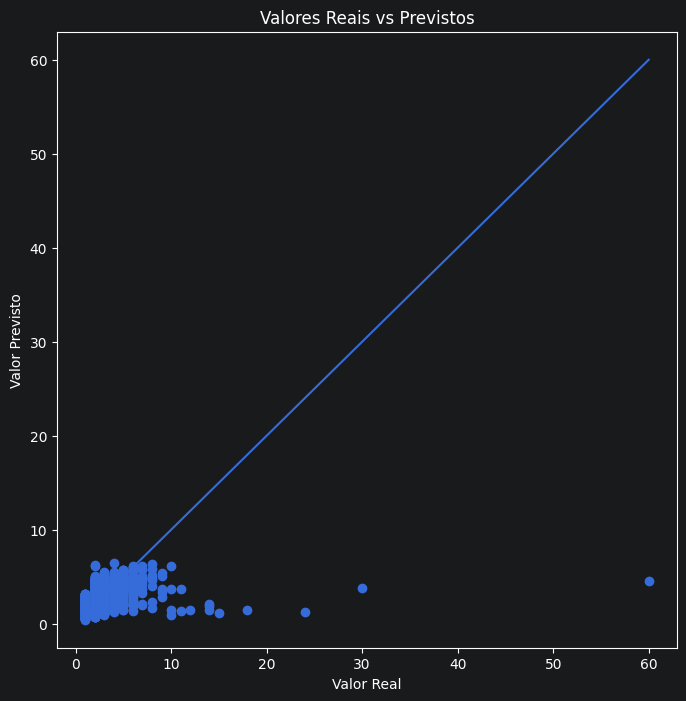

In [24]:
previsoes_lr = modelo_lr.predict(
    X_test
)

plt.figure(figsize=[8,8])

plt.scatter(

    y_test,
    previsoes_lr

)

plt.plot(

    [y_test.min(),y_test.max()],

    [y_test.min(),y_test.max()]

)

plt.title(
    'Valores Reais vs Previstos'
)

plt.xlabel(
    'Valor Real'
)

plt.ylabel(
    'Valor Previsto'
)

plt.show()

### Interpretação do desempenho do modelo

A comparação entre valores reais e previstos mostrou que o modelo apresentou desempenho mais consistente em cenários de demanda comum.

Entretanto, foram observadas dificuldades em prever eventos extremos ou picos elevados de vendas.

Esse comportamento sugere que:

- o modelo consegue capturar padrões gerais;
- demandas excepcionais permanecem difíceis de prever;
- eventos raros podem exigir modelos mais sofisticados ou variáveis adicionais.

Esse resultado é coerente com operações de TCG, nas quais lançamentos, promoções e alterações de meta podem gerar aumentos abruptos de demanda.

### Reflexão sobre a modelagem

Mercados de TCG apresentam características particulares, como lançamentos, alterações no meta competitivo e eventos promocionais capazes de gerar picos abruptos de demanda.

Durante a etapa de modelagem foi possível confirmar uma limitação esperada: embora o modelo tenha apresentado desempenho consistente para cenários de demanda comum, eventos extremos permaneceram significativamente mais difíceis de prever.

Esse comportamento reforça uma característica conhecida de mercados altamente dinâmicos: previsões exatas de quantidade podem apresentar limitações diante de comportamentos altamente voláteis.

Entretanto, esse resultado também reforça o objetivo central do CardFlow. Mais do que prever valores exatos, a proposta do projeto busca apoiar decisões operacionais por meio da identificação de padrões, riscos de ruptura e sinais antecipados de mudanças de demanda.

Assim, os resultados obtidos indicam que abordagens orientadas à classificação de risco e suporte à tomada de decisão podem representar uma evolução complementar para futuras versões do sistema.

## Detecção de Eventos Extremos

Durante a modelagem inicial foi observado que demandas excepcionais apresentam comportamento significativamente diferente dos cenários comuns.

Para complementar a solução, será criada uma segunda abordagem focada especificamente na identificação de explosões de demanda.

Nesse contexto, o problema deixa de ser:

"quantas unidades serão vendidas?"

e passa a ser:

"existe risco de um aumento incomum de demanda?"

In [25]:
# ======================
# Criação da variável:
# explosão de demanda
# ======================

limite = (

    base_ml[
        'quantidade_vendida'
    ]

    .quantile(
        0.95
    )

)

base_ml[
    'explosao_demanda'
] = (

    base_ml[
        'quantidade_vendida'
    ]

    >= limite

).astype(int)

print(
    'Limite:',
    limite
)

print('\nDistribuição:\n')

print(

    base_ml[
        'explosao_demanda'
    ]

    .value_counts()

)

print(

    '\nPercentual:\n'

)

print(

    round(

        base_ml[
            'explosao_demanda'
        ]

        .value_counts(
            normalize=True
        )*100,

        2

    )

)

Limite: 5.0

Distribuição:

explosao_demanda
0    17117
1     1161
Name: count, dtype: int64

Percentual:

explosao_demanda
0    93.65
1     6.35
Name: proportion, dtype: float64


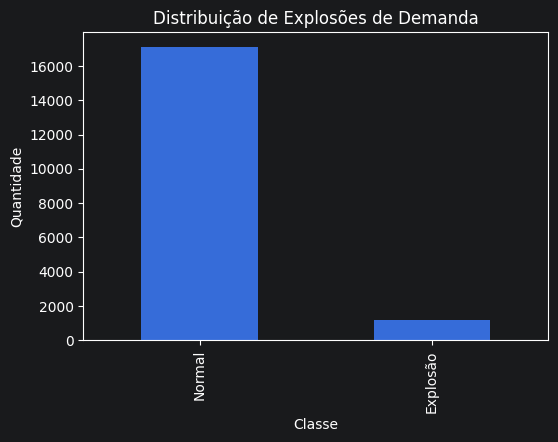

In [26]:
plt.figure(figsize=[6,4])

base_ml[
    'explosao_demanda'
].value_counts().plot(
    kind='bar'
)

plt.title(
    'Distribuição de Explosões de Demanda'
)

plt.xlabel(
    'Classe'
)

plt.ylabel(
    'Quantidade'
)

plt.xticks(
    [0,1],
    ['Normal','Explosão']
)

plt.show()

### Interpretação

A distribuição mostra que eventos extremos representam uma parcela pequena dos registros.

Esse comportamento é esperado em cenários reais: explosões de demanda tendem a ser raras, porém possuem alto impacto operacional.

### Balanceamento do problema

Foi identificado forte desbalanceamento entre as classes.

Esse comportamento é esperado em eventos raros, nos quais explosões de demanda representam pequena parcela dos registros.

Para evitar que o modelo aprenda predominantemente a classe majoritária, serão utilizadas técnicas de treinamento que considerem pesos entre as classes.

In [27]:
# ======================
# Variável alvo classificação
# ======================

target_clf='explosao_demanda'

X_clf = base_ml[features]

y_clf = base_ml[target_clf]

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(

    X_clf,
    y_clf,

    test_size=0.2,

    random_state=42,

    stratify=y_clf

)

print(X_train_clf.shape)

print(X_test_clf.shape)

print('\nTreino:')

print(

    y_train_clf.value_counts(
        normalize=True
    )

)

(14622, 21)
(3656, 21)

Treino:
explosao_demanda
0    0.936466
1    0.063534
Name: proportion, dtype: float64


In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression

preprocessador_clf = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            colunas_categoricas
        ),
        (
            'num',
            StandardScaler(),
            colunas_numericas
        )
    ]
)

modelo_explosao = Pipeline(
    steps=[
        ('preprocessador', preprocessador_clf),
        (
            'modelo',
            LogisticRegression(
                class_weight='balanced',
                max_iter=3000,
                solver='lbfgs'
            )
        )
    ]
)

modelo_explosao.fit(
    X_train_clf,
    y_train_clf
)

predicoes = modelo_explosao.predict(
    X_test_clf
)

print(
    classification_report(
        y_test_clf,
        predicoes
    )
)

              precision    recall  f1-score   support

           0       0.99      0.87      0.92      3424
           1       0.30      0.83      0.44       232

    accuracy                           0.86      3656
   macro avg       0.64      0.85      0.68      3656
weighted avg       0.94      0.86      0.89      3656



### Avaliação da detecção de explosões

O modelo apresentou recall elevado para eventos extremos, identificando aproximadamente 83% das explosões de demanda presentes no conjunto de teste.

Embora a precisão tenha permanecido moderada, esse comportamento é coerente com o objetivo operacional do CardFlow.

Em cenários de gestão de estoque, deixar de identificar uma explosão pode gerar ruptura e perda de vendas. Assim, gerar alguns alertas adicionais pode representar um custo menor do que ignorar eventos críticos.

Os resultados indicam que a abordagem apresenta potencial como mecanismo complementar de suporte à decisão.

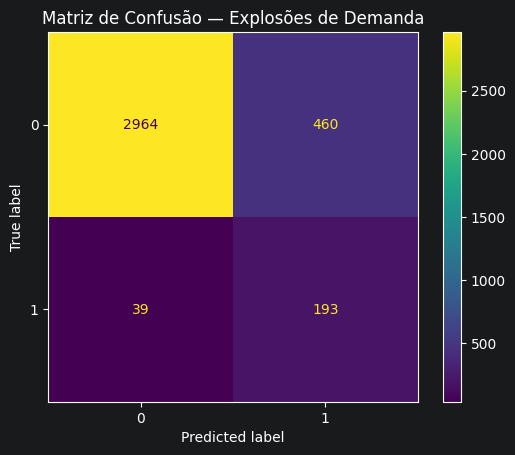

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(

    y_test_clf,
    predicoes

)

plt.title(
    'Matriz de Confusão — Explosões de Demanda'
)

plt.show()

### Interpretação da matriz de confusão

A matriz de confusão permite visualizar os diferentes tipos de acerto e erro produzidos pelo modelo.

Os resultados mostraram:

- 193 explosões foram corretamente identificadas;
- 39 explosões deixaram de ser detectadas;
- 460 alertas foram gerados sem ocorrência real de explosão;
- 2964 cenários normais foram classificados corretamente.

Esse comportamento evidencia um tradeoff importante: o modelo tende a gerar alertas adicionais para reduzir a quantidade de explosões não detectadas.

No contexto do CardFlow, essa estratégia pode ser aceitável em um MVP, já que o custo operacional de perder uma explosão de demanda pode ser maior do que gerar reposições preventivas extras.

Entretanto, os falsos positivos representam um ponto de atenção para futuras melhorias, pois alertas excessivos podem aumentar custos de estoque e reduzir eficiência operacional.

In [30]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf_explosao = Pipeline(

    steps=[

        (

            'preprocessador',
            preprocessador_clf

        ),

        (

            'modelo',

            RandomForestClassifier(

                n_estimators=200,

                max_depth=10,

                class_weight='balanced',

                random_state=42,

                n_jobs=-1

            )

        )

    ]

)

modelo_rf_explosao.fit(

    X_train_clf,
    y_train_clf

)

pred_rf = modelo_rf_explosao.predict(

    X_test_clf

)

print(

    classification_report(

        y_test_clf,

        pred_rf

    )

)

              precision    recall  f1-score   support

           0       0.98      0.89      0.93      3424
           1       0.32      0.76      0.45       232

    accuracy                           0.88      3656
   macro avg       0.65      0.82      0.69      3656
weighted avg       0.94      0.88      0.90      3656



### Comparação entre modelos de detecção

Foram avaliadas diferentes abordagens para identificação de explosões de demanda.

A Regressão Logística apresentou maior recall, identificando maior quantidade de explosões reais.

Já a Random Forest apresentou leve melhora em precisão e F1-score, reduzindo parte dos falsos alertas.

A escolha do modelo final considerou não apenas métricas estatísticas, mas também impacto operacional.

Como o objetivo principal do CardFlow é reduzir riscos de ruptura, optou-se por priorizar recall elevado, minimizando a quantidade de explosões não detectadas.

## Modelo adicional — Gradient Boosting

Além dos modelos anteriores, será avaliada uma abordagem baseada em boosting.

Modelos de boosting costumam apresentar bom desempenho em dados tabulares por combinarem múltiplos modelos fracos de forma sequencial, capturando padrões mais complexos.

In [31]:
from sklearn.ensemble import HistGradientBoostingClassifier

modelo_hgb_explosao = Pipeline(

    steps=[

        (
            'preprocessador',
            preprocessador_clf
        ),

        (

            'modelo',

            HistGradientBoostingClassifier(

                max_iter=200,

                learning_rate=0.05,

                max_leaf_nodes=31,

                random_state=42

            )

        )

    ]

)

modelo_hgb_explosao.fit(

    X_train_clf,
    y_train_clf

)

pred_hgb = modelo_hgb_explosao.predict(

    X_test_clf

)

print(

    classification_report(

        y_test_clf,

        pred_hgb

    )

)

              precision    recall  f1-score   support

           0       0.95      0.99      0.97      3424
           1       0.64      0.19      0.30       232

    accuracy                           0.94      3656
   macro avg       0.80      0.59      0.63      3656
weighted avg       0.93      0.94      0.93      3656



In [32]:
comparacao = pd.DataFrame({

'Modelo':[

'Logistic Regression',

'Random Forest',

'HistGradientBoosting'

],

'Precision':[

0.30,
0.32,
0.64

],

'Recall':[

0.83,
0.76,
0.19

],

'F1':[

0.44,
0.45,
0.30

]

})

display(comparacao)

,Modelo,Precision,Recall,F1
0,Logistic Regression,0.30,0.83,0.44
1,Random Forest,0.32,0.76,0.45
2,HistGradientBoosting,0.64,0.19,0.30


### Comparação final entre modelos

Foram avaliadas três abordagens para detecção de explosões de demanda:

- Regressão Logística;
- Random Forest;
- HistGradientBoosting.

Os resultados mostraram comportamentos distintos.

O HistGradientBoosting apresentou alta precisão, porém identificou pequena parcela das explosões reais.

A Random Forest apresentou equilíbrio ligeiramente superior em F1-score.

Entretanto, a Regressão Logística obteve maior recall, identificando aproximadamente 83% dos eventos extremos.

Como o objetivo do CardFlow é reduzir riscos operacionais relacionados à ruptura de estoque, optou-se por priorizar recall elevado.

Assim, a Regressão Logística foi selecionada como modelo principal para detecção de explosões.

In [33]:
import joblib

# ======================
# Salvar modelos
# ======================

joblib.dump(

    modelo_lr,

    '../dashboard/modelo_demanda.pkl'

)

joblib.dump(

    modelo_explosao,

    '../dashboard/modelo_explosao.pkl'

)

print(

    'Modelos salvos com sucesso.'

)

Modelos salvos com sucesso.


## Persistência dos Modelos

Os modelos treinados foram exportados para arquivos externos, permitindo reutilização futura sem necessidade de novo treinamento.

Essa abordagem possibilita integração posterior com dashboards, APIs ou aplicações de apoio à decisão.

## Conclusões Gerais

O projeto CardFlow simulou um ambiente operacional de e-commerce especializado em Trading Card Games (TCGs), incorporando características frequentemente observadas em cenários reais.

Ao longo do desenvolvimento foram realizadas etapas de:

- tratamento e limpeza de dados;
- engenharia de atributos;
- construção de indicadores;
- análise exploratória;
- modelagem preditiva;
- detecção de explosões de demanda.

Os experimentos mostraram que diferentes modelos apresentam comportamentos distintos dependendo do objetivo analisado.

Na previsão de demanda média, relações lineares apresentaram melhor desempenho.

Já para eventos extremos, a modelagem orientada à classificação mostrou-se mais adequada ao contexto do problema, permitindo identificar grande parte das explosões de demanda e apoiar ações preventivas relacionadas ao estoque.

## Próximos Passos

Possíveis evoluções futuras:

- integração com APIs reais de marketplaces TCG;
- previsão temporal individual por produto;
- aprimoramento da detecção de explosões;
- geração automática de alertas;
- dashboard interativo via Streamlit;
- monitoramento contínuo do estoque.